# Stock Comparison Tool

## 1. Problem Definition

**Research Question**: Which company performs better in terms of compound growth and risk-adjusted returns? 

**Theoretical Framework**:

The compound interest formula is the foundation of this analysis:

$$FV_n = C \times (1 + r)^n$$

Where:
- FV = Future Value (cumulative return)
- C = Initial investment ($10,000)
- r = Monthly return
- n = Number of months

This formula calculates how an investment grows over time when returns are reinvested.

## 2. Target User

- **Individual investors**: Seeking data-driven stock selection guidance
- **Financial analysts**: Comparing risk-return trade-offs across companies
- **Students**: Learning financial analysis and compound interest applications

## 3. Data Source

- **Primary Source**: WRDS (Wharton Research Data Services) - CRSP Monthly Stock Database
- **Benchmark Source**: CRSP S&P 500 Index (sprtrn)
- **Risk-Free Rate Source**: FRED 10-Year Treasury Yield (tby10)
- **Access Date**: April 21, 2026
- **Time Period**: January 2015 - December 2025 (11 years)
- **Key Variables**: Monthly returns (ret), date
- **Data Reliability**: CRSP is a widely used academic database for stock market research

## 4. How to Use

1. Run Cell 1 to connect to WRDS (enter your username and password)
2. Run Cell 2 to enter two stock tickers (e.g., AAPL, TSLA)
3. Run Cell 3 to start the analysis
4. The tool will automatically:
   - Download stock and benchmark data
   - Calculate 9 key metrics (total return, Sharpe ratio, volatility, etc.)
   - Generate 9 comparison charts
   - Provide investment recommendations

## 5. Metrics Explained

| Metric | Formula | What It Means |
|--------|---------|----------------|
| Total Return | (1 + r₁) × (1 + r₂) × ... - 1 | Total growth over the period |
| Annual Return | (Total Return)^(1/years) - 1 | Average yearly return |
| Volatility | Std(ret) × √12 | Price fluctuation (higher = riskier) |
| Sharpe Ratio | (Return - Risk-Free Rate) / Volatility | Risk-adjusted return (higher = better) |
| Max Drawdown | min(value / peak - 1) | Worst historical loss from peak |
| Win Rate | Positive months / Total months | Percentage of profitable months |
| Beta | Cov(stock, market) / Var(market) | Sensitivity to market (1 = same as market) |

## 6. Outputs Generated

The tool produces 9 charts:
1. Cumulative return comparison (with S&P 500 benchmark)
2. Total return bar chart
3. Annual return bar chart
4. Volatility comparison
5. Sharpe ratio comparison
6. Excess return vs S&P 500
7. Drawdown comparison
8. Rolling beta (12-month window)
9. Correlation heatmap

A comprehensive report and investment recommendation are also printed.

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Connecting to WRDS...")
db = wrds.Connection()
print("✅ Connected successfully!")

Connecting to WRDS...


Enter your WRDS username [ru]: ruuu
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Connected successfully!


In [3]:
# Get user input with examples
print("=" * 50)
print("STOCK COMPARISON TOOL")
print("=" * 50)
print("\nSupported tickers (with data in WRDS):")
print("   AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA, META")
print("   JPM, KO, WMT, PFE, NFLX, DIS, V, BAC")
print("-" * 50)

ticker1 = input("Enter first stock ticker: ").upper()
ticker2 = input("Enter second stock ticker: ").upper()

print(f"\n✅ You entered: {ticker1} and {ticker2}")
print("Now run Cell 3 to start the analysis.")

STOCK COMPARISON TOOL

Supported tickers (with data in WRDS):
   AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA, META
   JPM, KO, WMT, PFE, NFLX, DIS, V, BAC
--------------------------------------------------


Enter first stock ticker:  AAPL
Enter second stock ticker:  TSLA



✅ You entered: AAPL and TSLA
Now run Cell 3 to start the analysis.



🔍 Analyzing AAPL, TSLA, and S&P 500 benchmark...
✅ Found: AAPL -> PERMNO 14593
✅ Found: TSLA -> PERMNO 93436

📥 Downloading AAPL data...
   Downloaded 120 rows
📥 Downloading TSLA data...
   Downloaded 120 rows
📥 Downloading S&P 500 benchmark...
   Downloaded 120 rows
📥 Downloading risk-free rate (10-year Treasury)...
   ⚠️ Risk-free rate data not available, using 2% as default
   Downloaded 132 rows

📊 Calculating metrics...
   Risk-free rate used: 2.0%
✅ Metrics calculated!

📊 Calculating rolling beta...


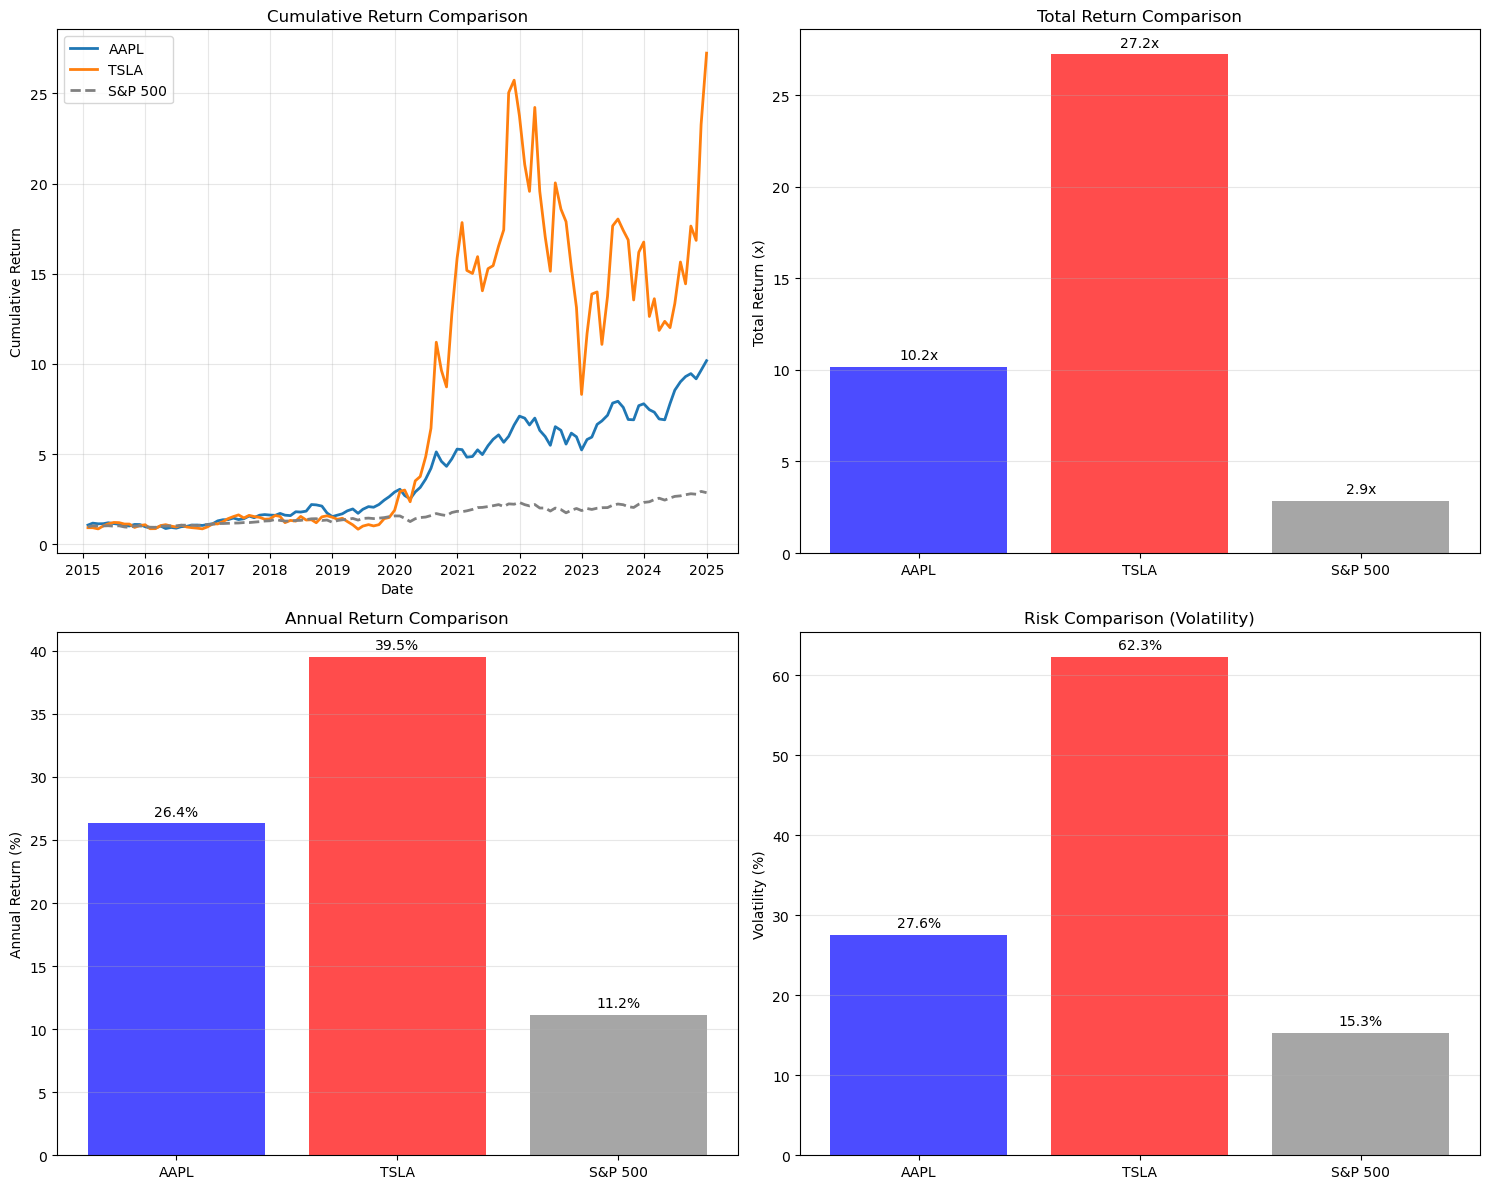

✅ Chart set 1 saved: comparison_charts.png


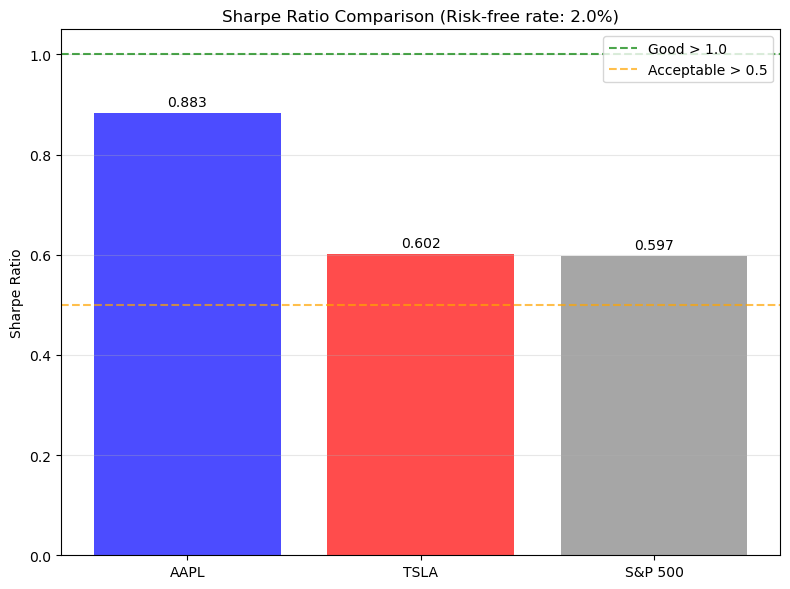

✅ Chart saved: sharpe_ratio_comparison.png


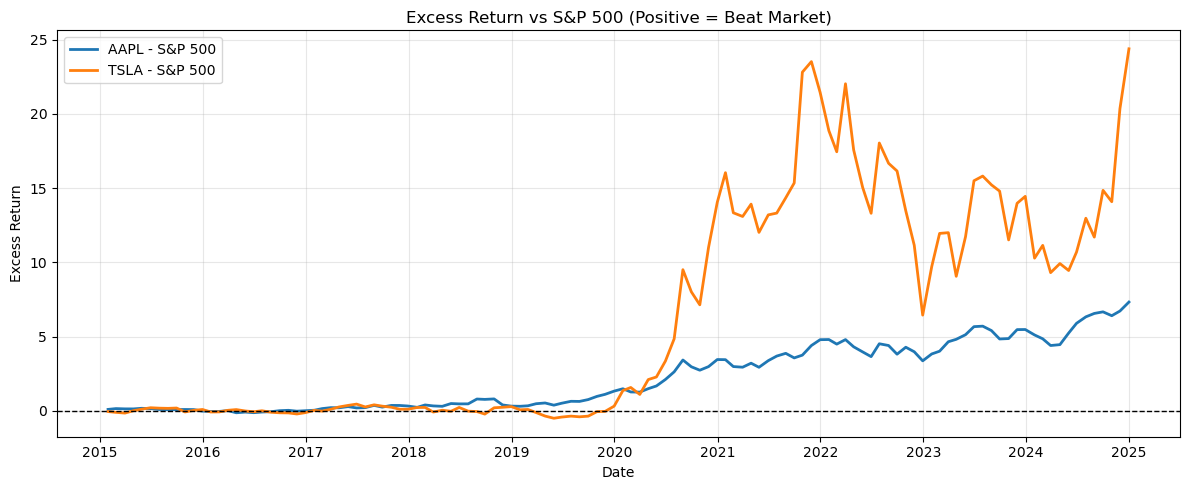

✅ Chart saved: excess_return_chart.png


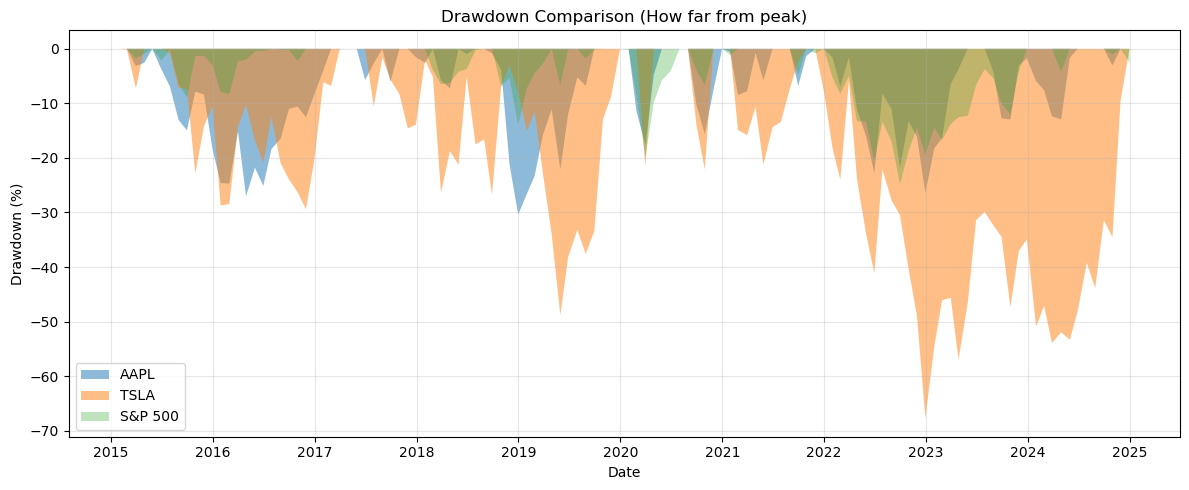

✅ Chart saved: drawdown_comparison.png


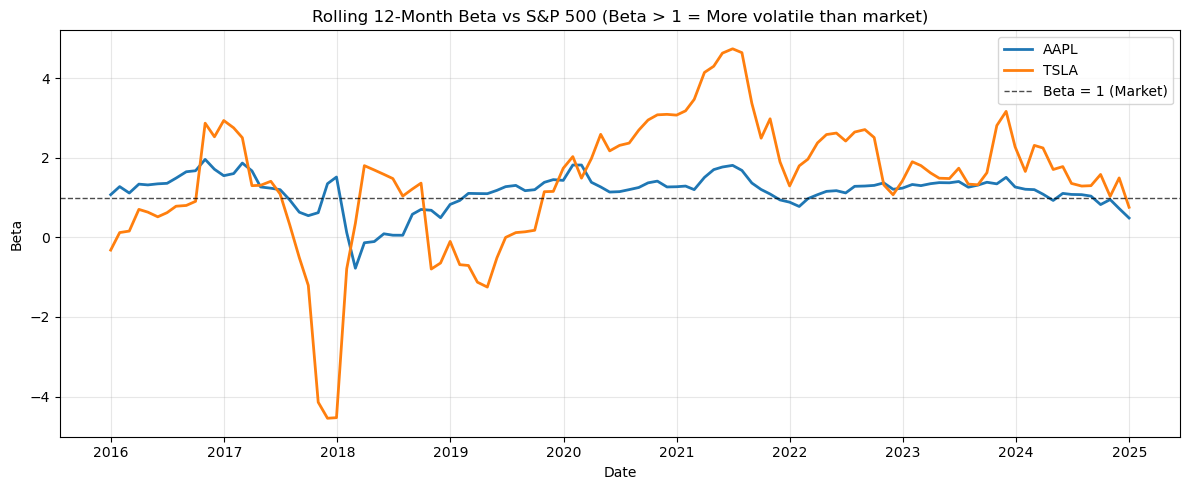

✅ Chart saved: rolling_beta.png


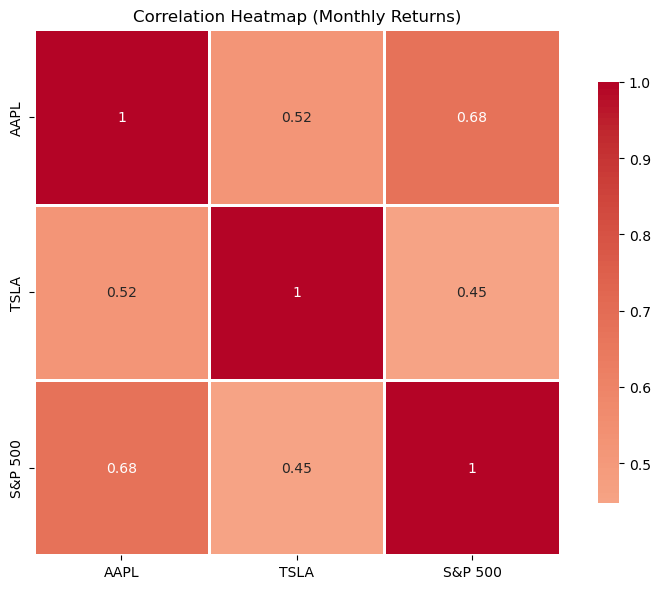

✅ Chart saved: correlation_heatmap.png

COMPREHENSIVE COMPARISON REPORT

Metric                         AAPL                 TSLA                 S&P 500             
------------------------------------------------------------------------------------------
Total Return (x)               10.18                27.24                2.86                
Total Return (%)               917.9                2623.6               185.7               
Annual Return (%)              26.35                39.54                11.16               
Volatility (%)                 27.58                62.34                15.34               
Sharpe Ratio                   0.883                0.602                0.597               
Max Drawdown (%)               -30.4                -67.7                -24.8               
Win Rate (%)                   57.5                 53.3                 66.7                
Future Value ($10k)            $101,793                  $272,362                  $

In [5]:
# ============================================================
# Stock Analysis - Run this cell after entering tickers
# ============================================================

print(f"\n🔍 Analyzing {ticker1}, {ticker2}, and S&P 500 benchmark...")

# ============================================================
# Helper functions
# ============================================================

def find_permno(ticker):
    sql = f"""
        SELECT permno, ticker, comnam
        FROM crsp.stocknames
        WHERE ticker = '{ticker}'
    """
    result = db.raw_sql(sql)
    return result.iloc[0]['permno'] if len(result) > 0 else None

def download_data(permno, start='2015-01-01', end='2025-12-31'):
    sql = f"""
        SELECT date, ret
        FROM crsp.msf
        WHERE permno = {permno}
            AND date >= '{start}'
            AND date <= '{end}'
        ORDER BY date
    """
    return db.raw_sql(sql)

def download_benchmark(start='2015-01-01', end='2025-12-31'):
    """Download S&P 500 benchmark data from CRSP msi table"""
    sql = f"""
        SELECT date, sprtrn as ret
        FROM crsp.msi
        WHERE date >= '{start}'
            AND date <= '{end}'
        ORDER BY date
    """
    return db.raw_sql(sql)

def download_risk_free_rate(start='2015-01-01', end='2025-12-31'):
    """Download 10-year Treasury yield as risk-free rate from FRED via WRDS"""
    try:
        sql = f"""
            SELECT date, tby10 as rf_rate
            FROM fred.tby10
            WHERE date >= '{start}'
                AND date <= '{end}'
            ORDER BY date
        """
        rf_data = db.raw_sql(sql)
        # Convert to monthly and average
        rf_data['date'] = pd.to_datetime(rf_data['date'])
        rf_data['year_month'] = rf_data['date'].dt.to_period('M')
        monthly_rf = rf_data.groupby('year_month')['rf_rate'].mean().reset_index()
        monthly_rf['date'] = monthly_rf['year_month'].dt.to_timestamp()
        monthly_rf = monthly_rf.drop(columns=['year_month'])
        return monthly_rf
    except:
        # Fallback to 2% if FRED data not available
        print("   ⚠️ Risk-free rate data not available, using 2% as default")
        dates = pd.date_range(start=start, end=end, freq='ME')  # Fixed: 'M' -> 'ME'
        return pd.DataFrame({'date': dates, 'rf_rate': 2.0})

def calculate_metrics(df, name, rf_series=None):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['ret'])
    if len(df) == 0:
        return None
    df = df.sort_values('date')
    df['cumulative_return'] = (1 + df['ret']).cumprod()
    
    n_years = (df['date'].max() - df['date'].min()).days / 365.25
    total_return = df['cumulative_return'].iloc[-1]
    annual_return = (total_return ** (1/n_years)) - 1
    annual_vol = df['ret'].std() * np.sqrt(12)
    
    # Calculate Sharpe ratio with dynamic risk-free rate
    if rf_series is not None:
        # Merge risk-free rate by date
        df_with_rf = df.merge(rf_series, on='date', how='left')
        df_with_rf['rf_rate'] = df_with_rf['rf_rate'].fillna(df_with_rf['rf_rate'].mean())
        avg_rf = df_with_rf['rf_rate'].mean() / 100  # Convert from percentage
    else:
        avg_rf = 0.02  # Default 2%
    
    sharpe = (annual_return - avg_rf) / annual_vol if annual_vol > 0 else 0
    
    df['cummax'] = df['cumulative_return'].cummax()
    df['drawdown'] = (df['cumulative_return'] - df['cummax']) / df['cummax']
    max_dd = df['drawdown'].min()
    win_rate = (df['ret'] > 0).mean()
    
    return {
        'name': name, 'df': df,
        'total_return': round(total_return, 2),
        'total_return_pct': round((total_return - 1) * 100, 1),
        'annual_return': round(annual_return * 100, 2),
        'volatility': round(annual_vol * 100, 2),
        'sharpe': round(sharpe, 3),
        'max_drawdown': round(max_dd * 100, 1),
        'win_rate': round(win_rate * 100, 1),
        'future_value': round(10000 * total_return, 0),
        'risk_free_rate': round(avg_rf * 100, 2),
    }

def calculate_rolling_beta(stock_returns, market_returns, window=12):
    """Calculate rolling beta between stock and market"""
    betas = []
    for i in range(window, len(stock_returns) + 1):
        stock_window = stock_returns.iloc[i-window:i]
        market_window = market_returns.iloc[i-window:i]
        if len(stock_window) == window and stock_window.std() > 0:
            cov = np.cov(stock_window, market_window)[0, 1]
            var = market_window.var()
            beta = cov / var if var > 0 else 1
        else:
            beta = 1
        betas.append(beta)
    return pd.Series(betas, index=stock_returns.index[window-1:])

# ============================================================
# Find PERMNO
# ============================================================

permno1 = find_permno(ticker1)
permno2 = find_permno(ticker2)

if permno1 is None:
    print(f"❌ ERROR: Could not find '{ticker1}'")
    print("   Examples: AAPL, MSFT, TSLA, AMZN, NVDA, GOOGL")
elif permno2 is None:
    print(f"❌ ERROR: Could not find '{ticker2}'")
    print("   Examples: AAPL, MSFT, TSLA, AMZN, NVDA, GOOGL")
else:
    print(f"✅ Found: {ticker1} -> PERMNO {permno1}")
    print(f"✅ Found: {ticker2} -> PERMNO {permno2}")

    # ============================================================
    # Download data
    # ============================================================
    
    print(f"\n📥 Downloading {ticker1} data...")
    data1 = download_data(permno1)
    print(f"   Downloaded {len(data1)} rows")
    
    print(f"📥 Downloading {ticker2} data...")
    data2 = download_data(permno2)
    print(f"   Downloaded {len(data2)} rows")
    
    print(f"📥 Downloading S&P 500 benchmark...")
    bench_data = download_benchmark()
    print(f"   Downloaded {len(bench_data)} rows")
    
    print(f"📥 Downloading risk-free rate (10-year Treasury)...")
    rf_data = download_risk_free_rate()
    print(f"   Downloaded {len(rf_data)} rows")
    
    if len(data1) == 0 or len(data2) == 0:
        print("\n❌ No data found for one or both tickers.")
    else:
        # ============================================================
        # Calculate metrics
        # ============================================================
        
        print("\n📊 Calculating metrics...")
        m1 = calculate_metrics(data1, ticker1, rf_data)
        m2 = calculate_metrics(data2, ticker2, rf_data)
        mb = calculate_metrics(bench_data, 'S&P 500', rf_data)
        
        if m1 and m2 and mb:
            print(f"   Risk-free rate used: {m1['risk_free_rate']}%")
            print("✅ Metrics calculated!\n")
            
            # Calculate rolling beta
            print("📊 Calculating rolling beta...")
            # Align dates
            common_dates = pd.Index(m1['df']['date']).intersection(mb['df']['date'])
            m1_aligned = m1['df'].set_index('date').loc[common_dates]['ret']
            m2_aligned = m2['df'].set_index('date').loc[common_dates]['ret']
            mb_aligned = mb['df'].set_index('date').loc[common_dates]['ret']
            
            beta1 = calculate_rolling_beta(m1_aligned, mb_aligned, 12)
            beta2 = calculate_rolling_beta(m2_aligned, mb_aligned, 12)
            
            # ============================================================
            # Generate charts - Figure 1 (4 charts)
            # ============================================================
            
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))
            
            # Chart 1: Cumulative returns
            ax1 = axes[0, 0]
            ax1.plot(m1['df']['date'], m1['df']['cumulative_return'], label=ticker1, linewidth=2)
            ax1.plot(m2['df']['date'], m2['df']['cumulative_return'], label=ticker2, linewidth=2)
            ax1.plot(mb['df']['date'], mb['df']['cumulative_return'], label='S&P 500', linewidth=2, color='gray', linestyle='--')
            ax1.set_xlabel('Date')
            ax1.set_ylabel('Cumulative Return')
            ax1.set_title('Cumulative Return Comparison')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Chart 2: Total Return
            ax2 = axes[0, 1]
            cats = [ticker1, ticker2, 'S&P 500']
            vals = [m1['total_return'], m2['total_return'], mb['total_return']]
            colors = ['blue', 'red', 'gray']
            bars = ax2.bar(cats, vals, color=colors, alpha=0.7)
            ax2.set_ylabel('Total Return (x)')
            ax2.set_title('Total Return Comparison')
            for bar, v in zip(bars, vals):
                ax2.annotate(f'{v:.1f}x', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
            ax2.grid(True, alpha=0.3, axis='y')
            
            # Chart 3: Annual Return
            ax3 = axes[1, 0]
            vals_ret = [m1['annual_return'], m2['annual_return'], mb['annual_return']]
            bars = ax3.bar(cats, vals_ret, color=colors, alpha=0.7)
            ax3.set_ylabel('Annual Return (%)')
            ax3.set_title('Annual Return Comparison')
            for bar, v in zip(bars, vals_ret):
                ax3.annotate(f'{v:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
            ax3.grid(True, alpha=0.3, axis='y')
            
            # Chart 4: Volatility
            ax4 = axes[1, 1]
            vals_vol = [m1['volatility'], m2['volatility'], mb['volatility']]
            bars = ax4.bar(cats, vals_vol, color=colors, alpha=0.7)
            ax4.set_ylabel('Volatility (%)')
            ax4.set_title('Risk Comparison (Volatility)')
            for bar, v in zip(bars, vals_vol):
                ax4.annotate(f'{v:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
            ax4.grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.savefig('comparison_charts.png', dpi=150)
            plt.show()
            print("✅ Chart set 1 saved: comparison_charts.png")
            
            # ============================================================
            # Chart 5: Sharpe Ratio
            # ============================================================
            
            fig2, ax5 = plt.subplots(figsize=(8, 6))
            sharpe_vals = [m1['sharpe'], m2['sharpe'], mb['sharpe']]
            bars = ax5.bar(cats, sharpe_vals, color=colors, alpha=0.7)
            ax5.set_ylabel('Sharpe Ratio')
            ax5.set_title(f'Sharpe Ratio Comparison (Risk-free rate: {m1["risk_free_rate"]}%)')
            ax5.axhline(y=1, color='green', linestyle='--', alpha=0.7, label='Good > 1.0')
            ax5.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Acceptable > 0.5')
            for bar, v in zip(bars, sharpe_vals):
                ax5.annotate(f'{v:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
            ax5.legend()
            ax5.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.savefig('sharpe_ratio_comparison.png', dpi=150)
            plt.show()
            print("✅ Chart saved: sharpe_ratio_comparison.png")
            
            # ============================================================
            # Chart 6: Excess Return
            # ============================================================
            
            fig3, ax6 = plt.subplots(figsize=(12, 5))
            min_len = min(len(m1['df']), len(m2['df']), len(mb['df']))
            excess1 = m1['df']['cumulative_return'].iloc[:min_len].values - mb['df']['cumulative_return'].iloc[:min_len].values
            excess2 = m2['df']['cumulative_return'].iloc[:min_len].values - mb['df']['cumulative_return'].iloc[:min_len].values
            
            ax6.plot(mb['df']['date'].iloc[:min_len], excess1, label=f'{ticker1} - S&P 500', linewidth=2)
            ax6.plot(mb['df']['date'].iloc[:min_len], excess2, label=f'{ticker2} - S&P 500', linewidth=2)
            ax6.axhline(y=0, color='black', linestyle='--', linewidth=1)
            ax6.set_xlabel('Date')
            ax6.set_ylabel('Excess Return')
            ax6.set_title('Excess Return vs S&P 500 (Positive = Beat Market)')
            ax6.legend()
            ax6.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('excess_return_chart.png', dpi=150)
            plt.show()
            print("✅ Chart saved: excess_return_chart.png")
            
            # ============================================================
            # Chart 7: Drawdown Comparison
            # ============================================================
            
            fig4, ax7 = plt.subplots(figsize=(12, 5))
            ax7.fill_between(m1['df']['date'], 0, m1['df']['drawdown'] * 100, label=ticker1, alpha=0.5)
            ax7.fill_between(m2['df']['date'], 0, m2['df']['drawdown'] * 100, label=ticker2, alpha=0.5)
            ax7.fill_between(mb['df']['date'], 0, mb['df']['drawdown'] * 100, label='S&P 500', alpha=0.3)
            ax7.set_xlabel('Date')
            ax7.set_ylabel('Drawdown (%)')
            ax7.set_title('Drawdown Comparison (How far from peak)')
            ax7.legend()
            ax7.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('drawdown_comparison.png', dpi=150)
            plt.show()
            print("✅ Chart saved: drawdown_comparison.png")
            
            # ============================================================
            # Chart 8: Rolling Beta
            # ============================================================
            
            fig5, ax8 = plt.subplots(figsize=(12, 5))
            ax8.plot(beta1.index, beta1.values, label=ticker1, linewidth=2)
            ax8.plot(beta2.index, beta2.values, label=ticker2, linewidth=2)
            ax8.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Beta = 1 (Market)')
            ax8.set_xlabel('Date')
            ax8.set_ylabel('Beta')
            ax8.set_title('Rolling 12-Month Beta vs S&P 500 (Beta > 1 = More volatile than market)')
            ax8.legend()
            ax8.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('rolling_beta.png', dpi=150)
            plt.show()
            print("✅ Chart saved: rolling_beta.png")
            
            # ============================================================
            # Chart 9: Correlation Heatmap (Fixed)
            # ============================================================
            
            fig6, ax9 = plt.subplots(figsize=(8, 6))
            
            # Align all three returns by date
            merged = m1['df'][['date', 'ret']].copy()
            merged = merged.rename(columns={'ret': ticker1})
            merged = merged.merge(m2['df'][['date', 'ret']], on='date')
            merged = merged.rename(columns={'ret': ticker2})
            merged = merged.merge(mb['df'][['date', 'ret']], on='date')
            merged = merged.rename(columns={'ret': 'S&P 500'})
            
            # Calculate correlation matrix
            corr_matrix = merged[[ticker1, ticker2, 'S&P 500']].corr()
            
            # Plot heatmap
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                       square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax9)
            ax9.set_title('Correlation Heatmap (Monthly Returns)')
            
            plt.tight_layout()
            plt.savefig('correlation_heatmap.png', dpi=150)
            plt.show()
            print("✅ Chart saved: correlation_heatmap.png")
            
            # ============================================================
            # Print report
            # ============================================================
            
            print("\n" + "="*80)
            print("COMPREHENSIVE COMPARISON REPORT")
            print("="*80)
            print(f"\n{'Metric':<30} {ticker1:<20} {ticker2:<20} {'S&P 500':<20}")
            print("-"*90)
            print(f"{'Total Return (x)':<30} {m1['total_return']:<20} {m2['total_return']:<20} {mb['total_return']:<20}")
            print(f"{'Total Return (%)':<30} {m1['total_return_pct']:<20} {m2['total_return_pct']:<20} {mb['total_return_pct']:<20}")
            print(f"{'Annual Return (%)':<30} {m1['annual_return']:<20} {m2['annual_return']:<20} {mb['annual_return']:<20}")
            print(f"{'Volatility (%)':<30} {m1['volatility']:<20} {m2['volatility']:<20} {mb['volatility']:<20}")
            print(f"{'Sharpe Ratio':<30} {m1['sharpe']:<20} {m2['sharpe']:<20} {mb['sharpe']:<20}")
            print(f"{'Max Drawdown (%)':<30} {m1['max_drawdown']:<20} {m2['max_drawdown']:<20} {mb['max_drawdown']:<20}")
            print(f"{'Win Rate (%)':<30} {m1['win_rate']:<20} {m2['win_rate']:<20} {mb['win_rate']:<20}")
            print(f"{'Future Value ($10k)':<30} ${m1['future_value']:,.0f}{' ':<17} ${m2['future_value']:,.0f}{' ':<17} ${mb['future_value']:,.0f}")
            print(f"{'Risk-Free Rate Used':<30} {m1['risk_free_rate']}%{' ':<18} {m2['risk_free_rate']}%{' ':<18} {mb['risk_free_rate']}%")
            
            # ============================================================
            # Recommendation
            # ============================================================
            
            print("\n" + "="*80)
            print("INVESTMENT RECOMMENDATION")
            print("="*80)
            
            print("\n📊 Performance vs S&P 500:")
            if m1['total_return'] > mb['total_return']:
                print(f"   ✅ {ticker1} outperformed S&P 500 by {m1['total_return'] - mb['total_return']:.2f}x")
            else:
                print(f"   ⚠️ {ticker1} underperformed S&P 500 by {mb['total_return'] - m1['total_return']:.2f}x")
            
            if m2['total_return'] > mb['total_return']:
                print(f"   ✅ {ticker2} outperformed S&P 500 by {m2['total_return'] - mb['total_return']:.2f}x")
            else:
                print(f"   ⚠️ {ticker2} underperformed S&P 500 by {mb['total_return'] - m2['total_return']:.2f}x")
            
            print("\n📈 Stock Comparison:")
            print(f"   Higher return: {ticker1 if m1['total_return'] > m2['total_return'] else ticker2}")
            print(f"   Lower risk: {ticker1 if m1['volatility'] < m2['volatility'] else ticker2}")
            print(f"   Better Sharpe ratio: {ticker1 if m1['sharpe'] > m2['sharpe'] else ticker2}")
            
            # Score
            score1 = m1['total_return'] * 10 + m1['sharpe'] * 10 + (100 - m1['volatility']) / 10
            score2 = m2['total_return'] * 10 + m2['sharpe'] * 10 + (100 - m2['volatility']) / 10
            
            print("\n" + "-"*50)
            print("FINAL VERDICT:")
            if score1 > score2:
                print(f"   🏆 Recommended: {ticker1}")
                print(f"   Score: {score1:.1f} vs {score2:.1f}")
            else:
                print(f"   🏆 Recommended: {ticker2}")
                print(f"   Score: {score2:.1f} vs {score1:.1f}")
            
            print("\n📌 Investment Advice:")
            print(f"   For growth: {ticker1 if m1['total_return'] > m2['total_return'] else ticker2}")
            print(f"   For safety: {ticker1 if m1['volatility'] < m2['volatility'] else ticker2}")
            print(f"   For risk-adjusted return: {ticker1 if m1['sharpe'] > m2['sharpe'] else ticker2}")
            print(f"   For balance: Consider holding both or adding S&P 500 ETF")

In [9]:
# Close connection
db.close()
print("\n✅ WRDS connection closed")


✅ WRDS connection closed
